# LSTM para detección de puntos de cambio en trayectorias de difusión anómala

Este cuaderno implementa una arquitectura LSTM para estimar la posición del punto de cambio en trayectorias sintéticas de difusión anómala. El protocolo se mantiene igual que en los modelos ConvLSTM, Transformer y ConvTransformer: se carga la base sintética ya generada, se entrena el modelo, se evalúa el error global y se analizan los resultados por transición ordenada entre modelos de difusión.

## 1. Importación de librerías

Se cargan únicamente las librerías necesarias para lectura de datos, entrenamiento del modelo, evaluación y visualización de resultados.

In [1]:
import random
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics, callbacks

## 2. Configuración experimental

Esta versión está preparada para ejecutar el entrenamiento completo solicitado: `FAST_RUN = False`, 200 000 trayectorias de entrenamiento, 20 000 de validación y 200 000 de prueba. El conjunto de prueba mantiene 10 000 trayectorias por cada transición ordenada entre modelos de difusión.

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

LENGTH = 100
MIN_SEGMENT_LENGTH = 20

MODELS = ["ATTM", "CTRW", "FBM", "LW", "SBM"]
TRANSITIONS = [(m1, m2) for m1 in MODELS for m2 in MODELS if m1 != m2]

FAST_RUN = False
FAST_TRAIN_SIZE = 200000
FAST_VAL_SIZE = 20000
FAST_TEST_SIZE = 200000

EPOCHS = 80
BATCH_SIZE = 256
PREDICT_BATCH_SIZE = 2048

DATA_DIR = Path("C:/Users/chair/Downloads/data_synthetic_changepoint_andi")
OUTPUT_DIR = Path("lstm_results_final")
OUTPUT_DIR.mkdir(exist_ok=True)

## 3. Carga de la base sintética

Cada archivo HDF5 contiene las trayectorias `X`, la posición real del punto de cambio `cp`, los modelos de difusión antes y después del cambio (`model1`, `model2`), los exponentes anómalos y el nivel de ruido. Los identificadores numéricos de los modelos se transforman a sus nombres: `ATTM`, `CTRW`, `FBM`, `LW` y `SBM`.

In [3]:
MODEL_MAP = {
    0: "ATTM",
    1: "CTRW",
    2: "FBM",
    3: "LW",
    4: "SBM",
}


def clean_model_name(value):
    if isinstance(value, bytes):
        value = value.decode("utf-8")

    if isinstance(value, np.generic):
        value = value.item()

    try:
        numeric_value = int(value)
        if numeric_value in MODEL_MAP:
            return MODEL_MAP[numeric_value]
    except (ValueError, TypeError):
        pass

    return str(value).replace("b'", "").replace("'", "").strip().upper()


def load_split(split_name):
    path = DATA_DIR / f"{split_name}_L100_dim1.h5"

    with h5py.File(path, "r") as file:
        x = file["X"][:].astype("float32")
        positions = file["cp"][:].astype("float32")
        model1 = [clean_model_name(v) for v in file["model1"][:]]
        model2 = [clean_model_name(v) for v in file["model2"][:]]
        alpha1 = file["alpha1"][:]
        alpha2 = file["alpha2"][:]
        noise_sigma = file["noise_sigma"][:]

    if x.ndim == 2:
        x = x[:, :, None]

    x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-8)
    y = (positions / LENGTH).astype("float32")

    metadata = pd.DataFrame({
        "cp": positions,
        "model1": model1,
        "model2": model2,
        "alpha1": alpha1,
        "alpha2": alpha2,
        "noise_sigma": noise_sigma,
    })
    metadata["transition"] = metadata["model1"] + " → " + metadata["model2"]

    return x, positions, y, metadata


def balanced_fast_subset(x, positions, y, metadata, total_size, seed=42):
    rng = np.random.default_rng(seed)
    groups = metadata.groupby(["model1", "model2"], sort=False).indices
    per_group = max(1, total_size // len(groups))
    selected = []

    for indices in groups.values():
        indices = np.array(list(indices))
        size = min(per_group, len(indices))
        selected.extend(rng.choice(indices, size=size, replace=False))

    selected = np.array(selected, dtype=int)
    rng.shuffle(selected)

    return (
        x[selected],
        positions[selected],
        y[selected],
        metadata.iloc[selected].reset_index(drop=True),
    )

## 4. Preparación para el entrenamiento

Antes de entrenar el modelo, las trayectorias se organizan con la forma adecuada para la red neuronal y se normalizan para que todas tengan una escala comparable. Esta etapa permite reducir el efecto de la amplitud de cada trayectoria y centrar el aprendizaje en los cambios de dinámica.

La variable de salida corresponde al punto de cambio normalizado entre 0 y 1. Después de la predicción, este valor se transforma de nuevo a puntos temporales para calcular métricas como MAE y RMSE.

Con esta preparación, el modelo puede entrenarse directamente sobre las trayectorias sintéticas de longitud **L = 100** y evaluarse después por transición ordenada entre modelos de difusión.

In [4]:
x_train, train_positions, y_train, train_metadata = load_split("train")
x_val, val_positions, y_val, val_metadata = load_split("val")
x_test, test_positions, y_test, test_metadata = load_split("test")

if FAST_RUN:
    x_train, train_positions, y_train, train_metadata = balanced_fast_subset(
        x_train, train_positions, y_train, train_metadata, FAST_TRAIN_SIZE, SEED
    )
    x_val, val_positions, y_val, val_metadata = balanced_fast_subset(
        x_val, val_positions, y_val, val_metadata, FAST_VAL_SIZE, SEED
    )
    x_test, test_positions, y_test, test_metadata = balanced_fast_subset(
        x_test, test_positions, y_test, test_metadata, FAST_TEST_SIZE, SEED
    )

split_size_frame = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "trajectories": [len(x_train), len(x_val), len(x_test)],
    "x_shape": [x_train.shape, x_val.shape, x_test.shape],
})

split_size_frame

,split,trajectories,x_shape
0,train,200000,"(200000, 100, 1)"
1,validation,20000,"(20000, 100, 1)"
2,test,200000,"(200000, 100, 1)"


In [5]:
test_transition_counts = (
    test_metadata["transition"]
    .value_counts()
    .reindex([f"{m1} → {m2}" for m1, m2 in TRANSITIONS], fill_value=0)
)

test_transition_counts.to_frame("samples")

,samples
transition,
ATTM → CTRW,10000
ATTM → FBM,10000
ATTM → LW,10000
ATTM → SBM,10000
CTRW → ATTM,10000
CTRW → FBM,10000
CTRW → LW,10000
CTRW → SBM,10000
FBM → ATTM,10000


## 5. Visualización inicial

Se muestran algunas trayectorias del conjunto de entrenamiento. La línea vertical discontinua indica la posición real del punto de cambio.

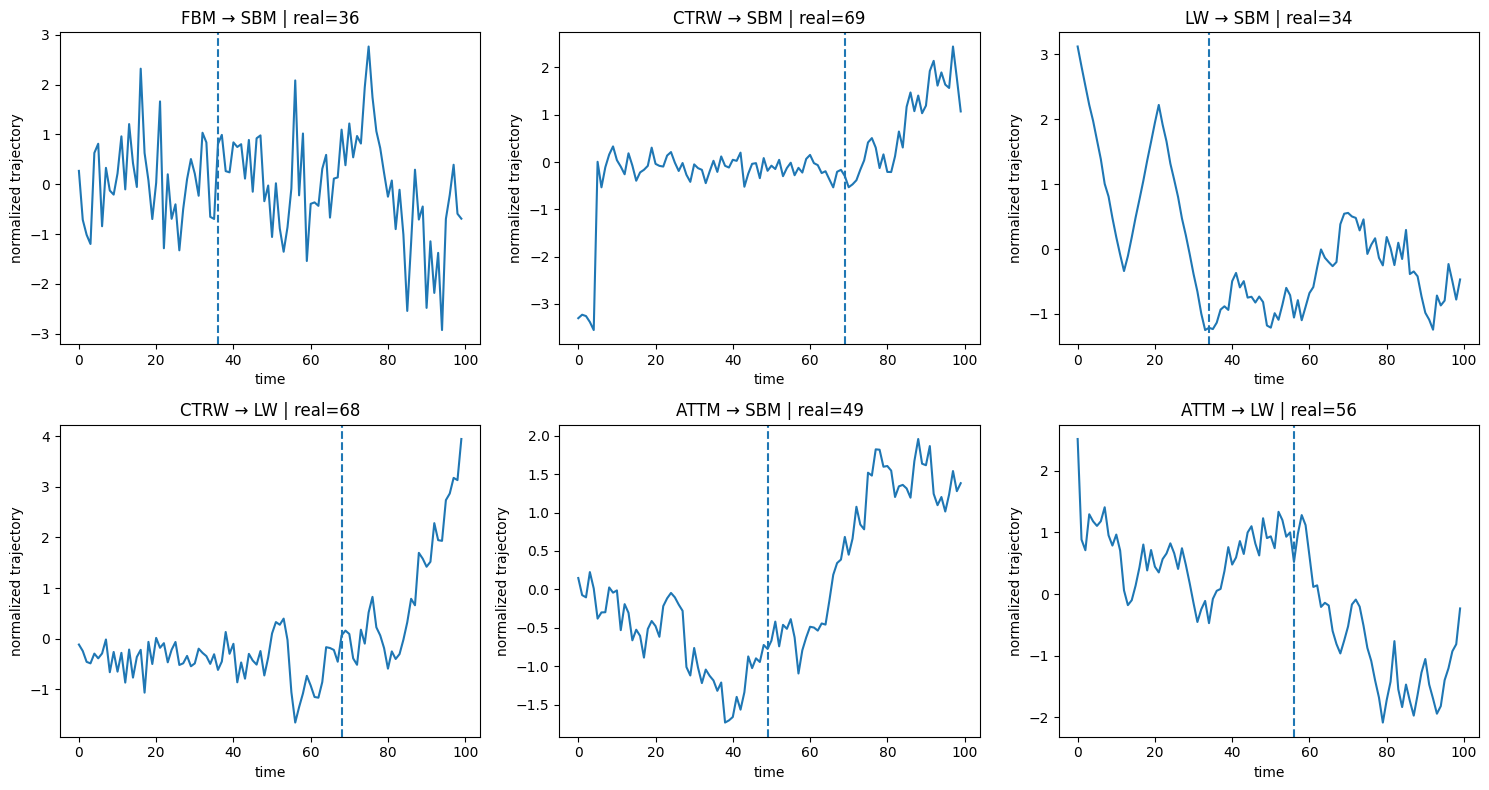

In [6]:
def plot_examples(x, positions, metadata, n_examples=6):
    n_examples = min(n_examples, len(x))
    selected = np.random.choice(len(x), size=n_examples, replace=False)
    columns = 3
    rows = int(np.ceil(n_examples / columns))

    plt.figure(figsize=(15, 4 * rows))

    for panel, index in enumerate(selected, start=1):
        values = x[index, :, 0]
        row = metadata.iloc[index]

        plt.subplot(rows, columns, panel)
        plt.plot(values)
        plt.axvline(int(positions[index]), linestyle="--")
        plt.title(f"{row['model1']} → {row['model2']} | real={int(positions[index])}")
        plt.xlabel("time")
        plt.ylabel("normalized trajectory")

    plt.tight_layout()
    plt.show()


plot_examples(x_train, train_positions, train_metadata)

## 6. Construcción del modelo LSTM

El modelo LSTM se diseñó para procesar cada trayectoria como una secuencia temporal. La arquitectura utiliza varias capas recurrentes que permiten conservar información de los puntos anteriores y aprender la evolución de la señal alrededor del punto de cambio.

Las capas iniciales mantienen la dimensión temporal completa, mientras que la última genera una representación resumida de la trayectoria. Después se aplican normalización, dropout y capas densas para obtener una única salida normalizada entre 0 y 1.

In [7]:
def build_lstm_changepoint_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.LSTM(128, return_sequences=True)(inputs)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.20)(x)
    x = layers.LSTM(32)(x)
    x = layers.Dropout(0.20)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.10)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="lstm_changepoint_regressor")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
        loss=losses.Huber(delta=0.05),
        metrics=[metrics.MeanAbsoluteError(name="mae")],
    )
    return model


model = build_lstm_changepoint_model(input_shape=x_train.shape[1:])
model.summary()

Model: "lstm_changepoint_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 100, 1)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization                  │ (None, 100, 128)            │             256 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 64)             │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization_1                │ (None, 100, 64)             │             128 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 130,945 (511.50 KB)

 Trainable params: 130,945 (511.50 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento

El entrenamiento se realizó con `FAST_RUN = False`, utilizando el conjunto completo de datos: 200.000 trayectorias para entrenamiento y 20.000 para validación. El modelo se entrenó con un máximo de 80 épocas y un tamaño de lote de 256.

Para controlar el aprendizaje se usaron `EarlyStopping`, reducción de la tasa de aprendizaje y guardado automático del mejor modelo según el error de validación. De esta forma, la evaluación final se hizo con la mejor versión obtenida durante el entrenamiento.

In [8]:
early_stop = callbacks.EarlyStopping(
    monitor="val_mae",
    patience=10,
    restore_best_weights=True,
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5,
)

model_checkpoint = callbacks.ModelCheckpoint(
    OUTPUT_DIR / "best_lstm_changepoint.keras",
    monitor="val_mae",
    save_best_only=True,
)

csv_logger = callbacks.CSVLogger(
    OUTPUT_DIR / "lstm_training_log.csv",
    append=False,
)

backup = callbacks.BackupAndRestore(
    backup_dir=OUTPUT_DIR / "training_backup",
)

In [9]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop, reduce_lr, model_checkpoint, csv_logger, backup],
    verbose=1,
)

Epoch 1/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 1741s 2s/step - loss: 0.0062 - mae: 0.1470 - val_loss: 0.0058 - val_mae: 0.1393 - learning_rate: 0.0010
Epoch 2/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 1705s 2s/step - loss: 0.0056 - mae: 0.1359 - val_loss: 0.0055 - val_mae: 0.1319 - learning_rate: 0.0010
Epoch 3/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 1740s 2s/step - loss: 0.0052 - mae: 0.1276 - val_loss: 0.0049 - val_mae: 0.1203 - learning_rate: 0.0010
Epoch 4/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 2237s 3s/step - loss: 0.0048 - mae: 0.1188 - val_loss: 0.0045 - val_mae: 0.1127 - learning_rate: 0.0010
Epoch 5/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 745s 919ms/step - loss: 0.0044 - mae: 0.1101 - val_loss: 0.0041 - val_mae: 0.1042 - learning_rate: 0.0010
Epoch 6/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 789s 1s/step - loss: 0.0041 - mae: 0.1033 - val_loss: 0.0038 - val_mae: 0.0974 - learning_rate: 0.0010
Epoch 7/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 771s 985ms/step - loss: 0.0039 - mae: 0.0981 - val_loss: 0.0038 - val_mae: 0.0980 - learning_ra

## 8. Evolución del entrenamiento

La pérdida permite observar la evolución del aprendizaje. El MAE se multiplica por `100` para interpretarlo directamente como error medio en puntos de la trayectoria.

,loss,mae,val_loss,val_mae,learning_rate
63,0.002543,0.069208,0.002916,0.078151,0.00001
64,0.002541,0.069156,0.002917,0.078177,0.00001
65,0.002545,0.069217,0.002918,0.078210,0.00001
66,0.002542,0.069181,0.002919,0.078225,0.00001
67,0.002543,0.069188,0.002918,0.078199,0.00001


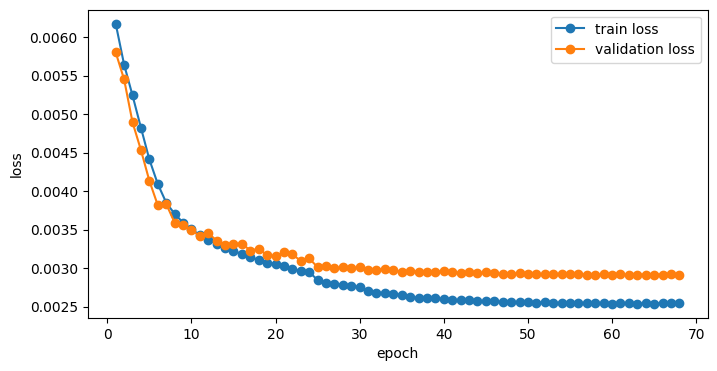

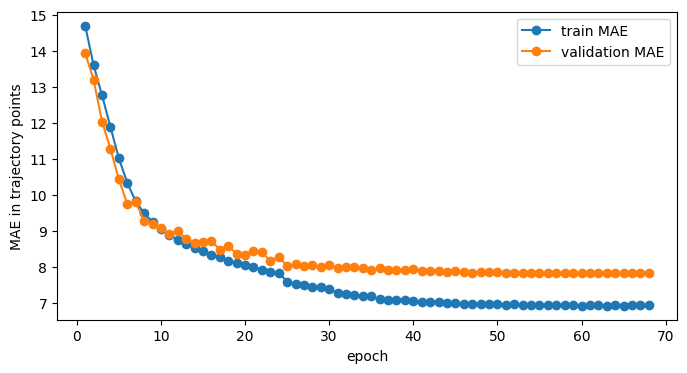

In [10]:
history_frame = pd.DataFrame(history.history)
display(history_frame.tail())

epochs_range = range(1, len(history_frame) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history_frame["loss"], marker="o", label="train loss")
plt.plot(epochs_range, history_frame["val_loss"], marker="o", label="validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history_frame["mae"] * LENGTH, marker="o", label="train MAE")
plt.plot(epochs_range, history_frame["val_mae"] * LENGTH, marker="o", label="validation MAE")
plt.xlabel("epoch")
plt.ylabel("MAE in trajectory points")
plt.legend()
plt.show()

## 9. Evaluación global en test

Las predicciones normalizadas se convierten a posiciones reales dentro de la trayectoria. El error se mide en número de puntos temporales.

In [11]:
def predict_positions(model, x):
    predicted_normalized = model.predict(x, batch_size=PREDICT_BATCH_SIZE, verbose=1).reshape(-1)
    predicted_positions = np.rint(predicted_normalized * LENGTH).astype(np.int32)
    predicted_positions = np.clip(predicted_positions, MIN_SEGMENT_LENGTH, LENGTH - MIN_SEGMENT_LENGTH)
    return predicted_positions, predicted_normalized


predicted_test_positions, predicted_test_normalized = predict_positions(model, x_test)

test_mae = mean_absolute_error(test_positions, predicted_test_positions)
test_rmse = np.sqrt(mean_squared_error(test_positions, predicted_test_positions))

global_metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE"],
    "value_in_points": [test_mae, test_rmse],
})

global_metrics

98/98 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step


,metric,value_in_points
0,MAE,7.717000
1,RMSE,11.706256


## 10. Resultados por pareja de modelos

Se evalúa el modelo para cada transición ordenada. `model1` representa el primer segmento de la trayectoria y `model2` representa el segundo segmento.

In [12]:
result_frame = test_metadata.copy().reset_index(drop=True)
result_frame["true_changepoint"] = test_positions
result_frame["predicted_changepoint"] = predicted_test_positions
result_frame["error"] = result_frame["predicted_changepoint"] - result_frame["true_changepoint"]
result_frame["absolute_error"] = result_frame["error"].abs()
result_frame["predicted_normalized"] = predicted_test_normalized

pair_metrics = (
    result_frame
    .groupby(["model1", "model2"])
    .agg(
        samples=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        rmse=("error", lambda values: float(np.sqrt(np.mean(np.square(values))))),
        median_absolute_error=("absolute_error", "median"),
        mean_bias=("error", "mean"),
    )
    .reset_index()
)

pair_metrics["transition"] = pair_metrics["model1"] + " → " + pair_metrics["model2"]
pair_metrics = pair_metrics[["transition", "model1", "model2", "samples", "mae", "rmse", "median_absolute_error", "mean_bias"]]
pair_metrics = pair_metrics.sort_values("mae").reset_index(drop=True)

pair_metrics

,transition,model1,model2,samples,mae,rmse,median_absolute_error,mean_bias
0,CTRW → LW,CTRW,LW,10000,3.6942,5.796827,3.0,0.4276
1,LW → CTRW,LW,CTRW,10000,3.9594,6.259073,3.0,0.6686
2,ATTM → LW,ATTM,LW,10000,5.3890,8.578706,3.0,0.0900
3,LW → ATTM,LW,ATTM,10000,5.5924,8.923788,3.0,1.6744
4,LW → SBM,LW,SBM,10000,5.9257,9.451100,3.0,1.2311
5,SBM → LW,SBM,LW,10000,6.1974,9.658809,4.0,-0.4278
6,CTRW → FBM,CTRW,FBM,10000,6.2627,10.085747,3.0,1.0629
7,CTRW → SBM,CTRW,SBM,10000,6.2720,9.886172,4.0,1.5056
8,LW → FBM,LW,FBM,10000,6.3673,10.201495,3.0,1.7921
9,FBM → LW,FBM,LW,10000,6.4348,10.169130,4.0,-0.4942


## 11. Mapa de error por transición

La matriz resume el MAE para cada pareja ordenada de modelos. Las filas representan el modelo del primer segmento y las columnas el modelo del segundo segmento.

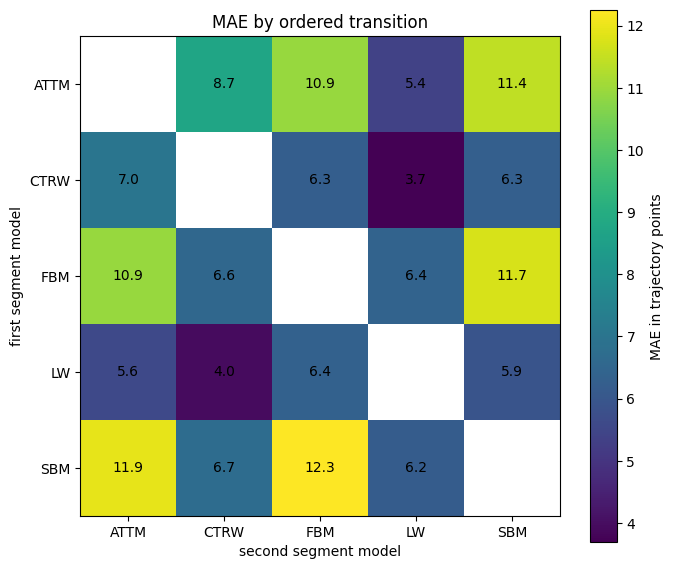

In [13]:
heatmap = pd.DataFrame(np.nan, index=MODELS, columns=MODELS)

for _, row in pair_metrics.iterrows():
    if row["model1"] in MODELS and row["model2"] in MODELS:
        heatmap.loc[row["model1"], row["model2"]] = row["mae"]

plt.figure(figsize=(7, 6))
plt.imshow(heatmap.values.astype(float))
plt.xticks(range(len(MODELS)), MODELS)
plt.yticks(range(len(MODELS)), MODELS)
plt.xlabel("second segment model")
plt.ylabel("first segment model")
plt.title("MAE by ordered transition")
plt.colorbar(label="MAE in trajectory points")

for i in range(len(MODELS)):
    for j in range(len(MODELS)):
        value = heatmap.iloc[i, j]
        if np.isfinite(value):
            plt.text(j, i, f"{value:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## 12. Panel con puntos reales y predichos

Para cada transición se selecciona una trayectoria representativa. La línea discontinua indica el punto real de cambio y la línea continua indica la predicción del modelo LSTM.

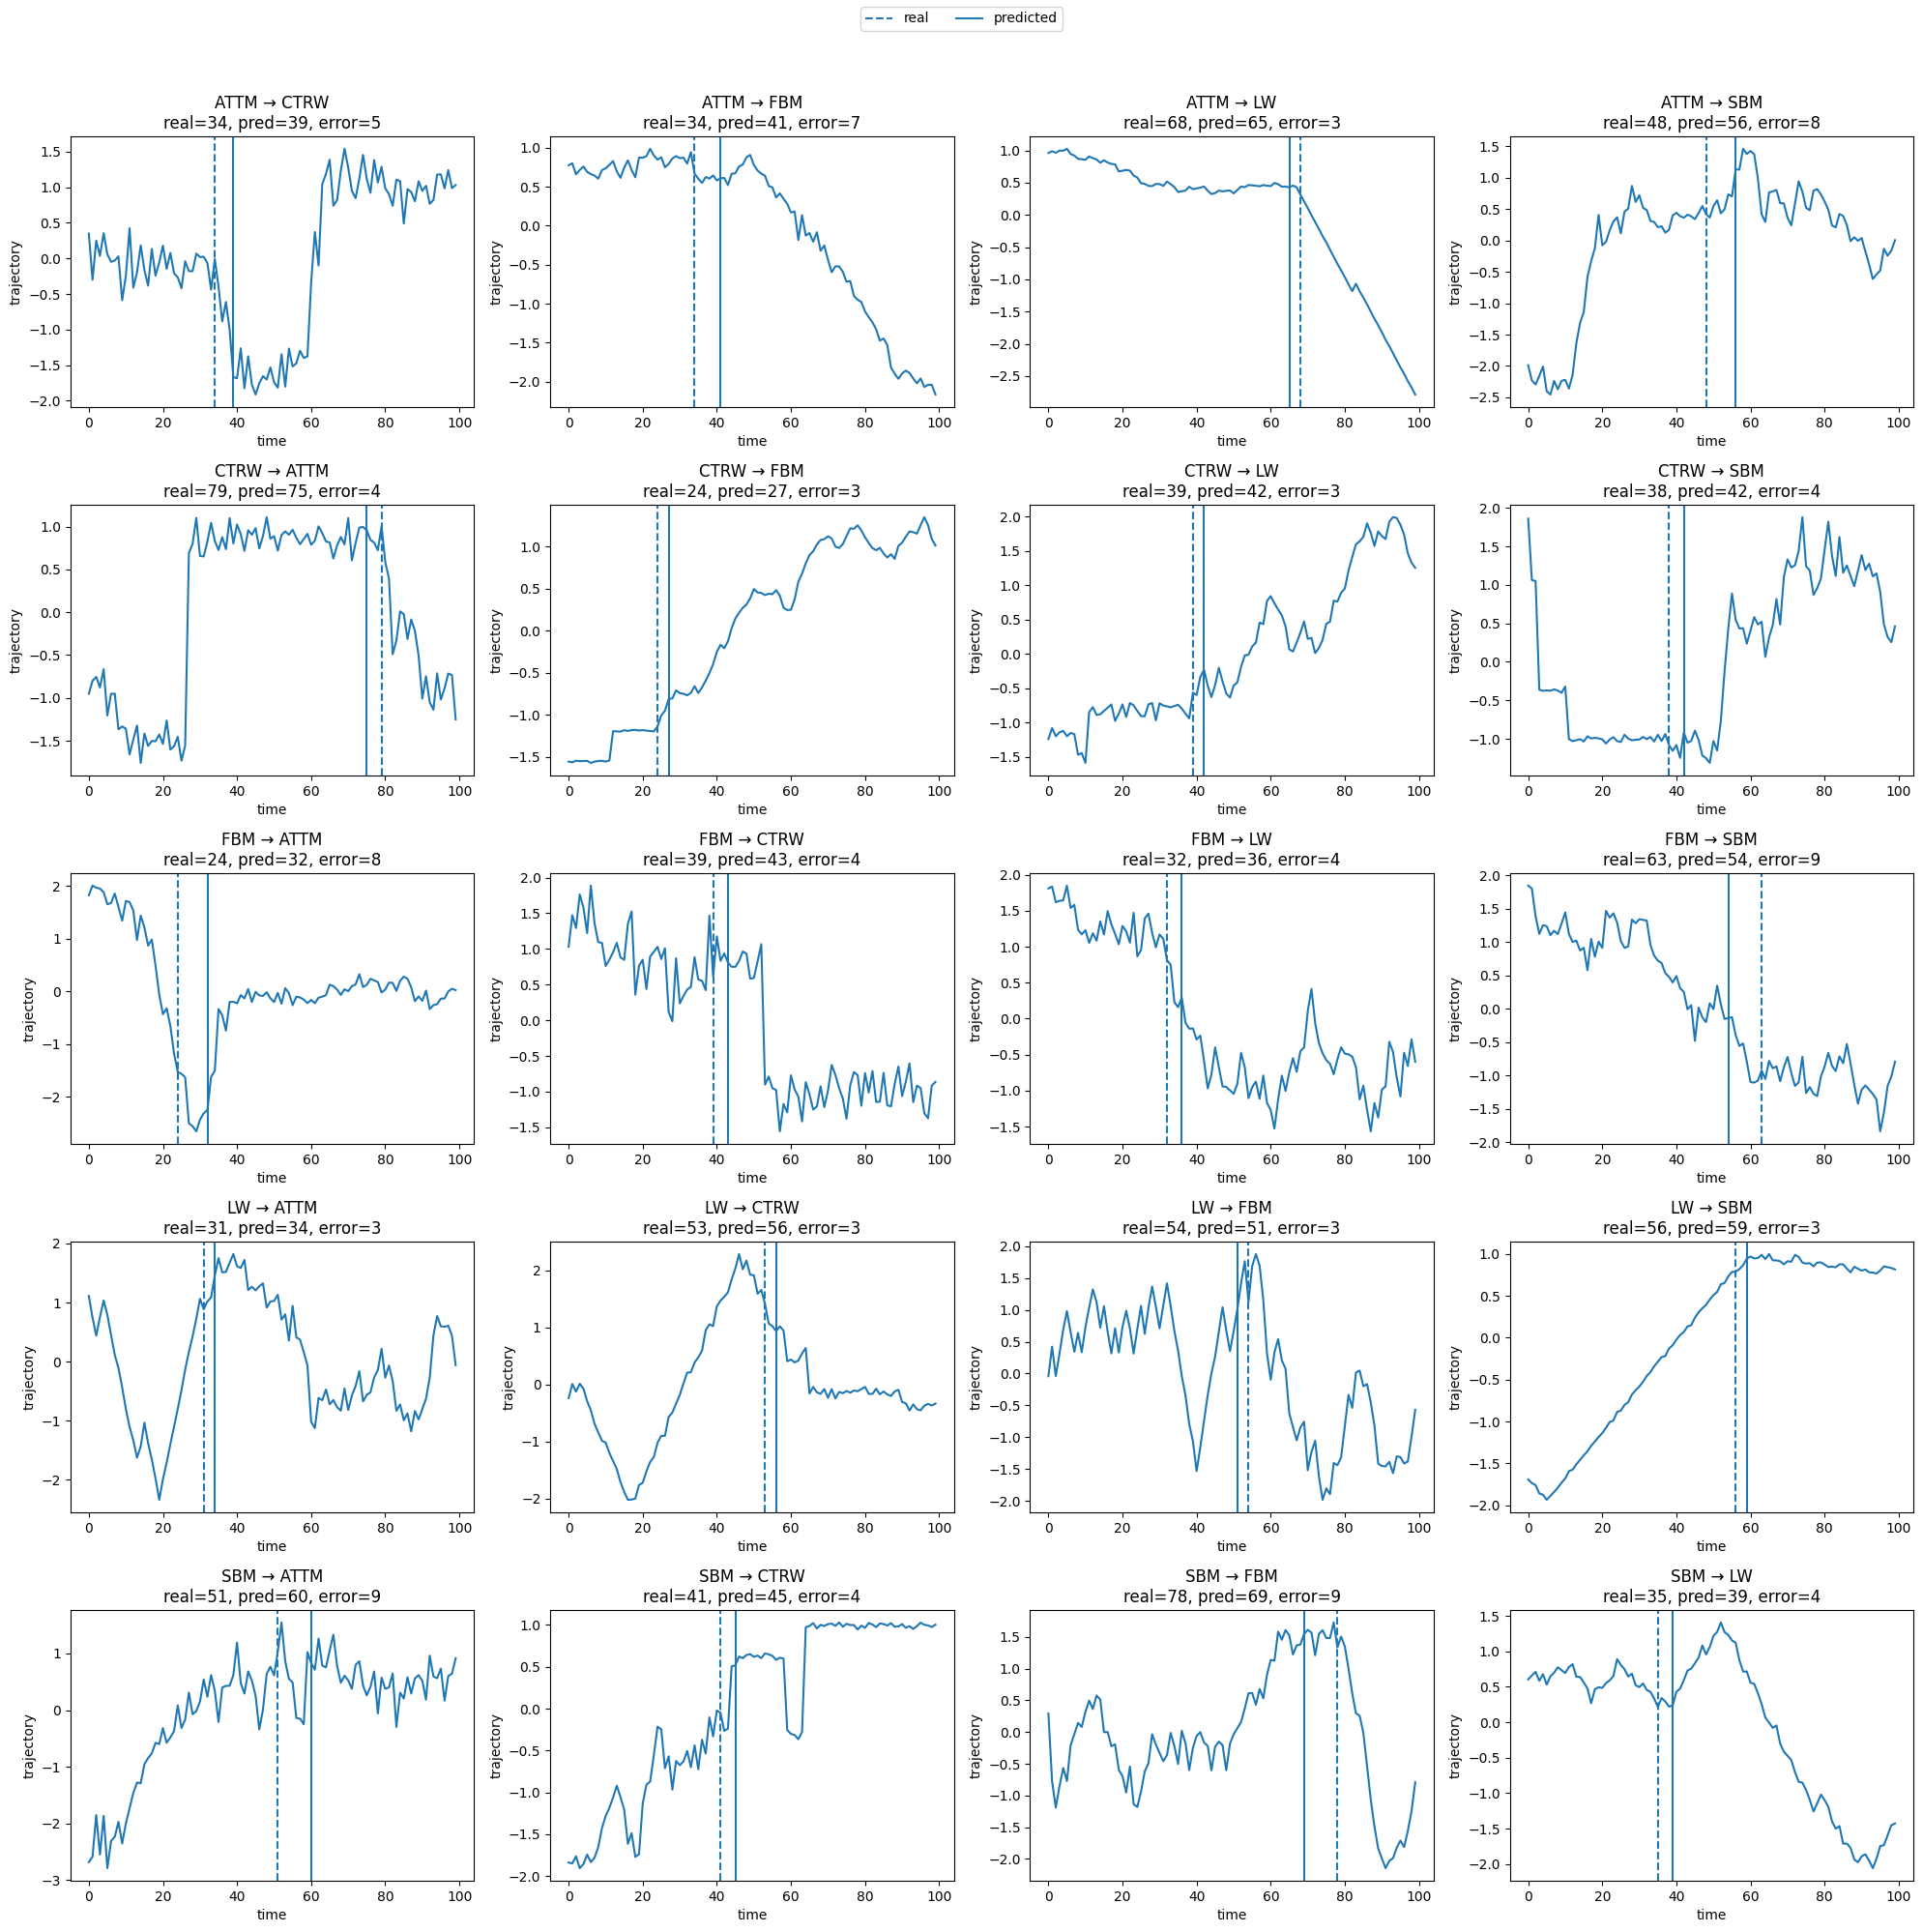

In [14]:
def representative_index_for_pair(frame, model1, model2):
    candidates = frame[(frame["model1"] == model1) & (frame["model2"] == model2)]

    if candidates.empty:
        return None

    target_error = candidates["absolute_error"].median()
    distances = (candidates["absolute_error"] - target_error).abs()

    return int(distances.idxmin())


def plot_transition_panel(x, results, max_pairs=20):
    selected_pairs = TRANSITIONS[:max_pairs]
    columns = 4
    rows = int(np.ceil(len(selected_pairs) / columns))

    plt.figure(figsize=(20, 4 * rows))

    for panel, (model1, model2) in enumerate(selected_pairs, start=1):
        index = representative_index_for_pair(results, model1, model2)

        plt.subplot(rows, columns, panel)

        if index is None:
            plt.title(f"{model1} → {model2}\nno data")
            plt.axis("off")
            continue

        values = x[index, :, 0]
        real_position = int(results.loc[index, "true_changepoint"])
        predicted_position = int(results.loc[index, "predicted_changepoint"])
        absolute_error = float(results.loc[index, "absolute_error"])

        plt.plot(values)
        plt.axvline(real_position, linestyle="--", label="real")
        plt.axvline(predicted_position, linestyle="-", label="predicted")

        plt.title(
            f"{model1} → {model2}\n"
            f"real={real_position}, pred={predicted_position}, error={absolute_error:.0f}"
        )

        plt.xlabel("time")
        plt.ylabel("trajectory")

    handles, labels = plt.gca().get_legend_handles_labels()

    if handles:
        plt.figlegend(handles, labels, loc="upper center", ncol=2)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


plot_transition_panel(x_test, result_frame)

## 13. Guardado de resultados

Se guardan las métricas globales, las métricas por transición y las predicciones individuales para poder comparar esta arquitectura con ConvLSTM, Transformer y ConvTransformer.

In [15]:
global_metrics.to_csv(OUTPUT_DIR / "lstm_global_metrics.csv", index=False)
pair_metrics.to_csv(OUTPUT_DIR / "lstm_pair_metrics.csv", index=False)
result_frame.to_csv(OUTPUT_DIR / "lstm_test_predictions.csv", index=False)
model.save(OUTPUT_DIR / "lstm_changepoint_final.keras")

OUTPUT_DIR

WindowsPath('lstm_results_final')

## Conclusión

El modelo LSTM fue aplicado a trayectorias sintéticas de longitud **L = 100**, compuestas por dos segmentos con modelos de difusión diferentes. El objetivo fue estimar la posición donde ocurre el cambio entre ambos fragmentos.

La base de datos se utilizó de forma completa, con **200.000 trayectorias para entrenamiento**, **20.000 para validación** y **200.000 para prueba**. En el conjunto de test, cada una de las 20 transiciones ordenadas contiene **10.000 trayectorias**.

Los resultados muestran un **MAE = 7.72** y un **RMSE = 11.71** puntos temporales. Esto indica que el modelo localiza el cambio con un error medio inferior a ocho posiciones dentro de trayectorias cortas.

El rendimiento cambia según la pareja de modelos. Las transiciones **CTRW → LW** y **LW → CTRW** presentan los errores más bajos, mientras que combinaciones como **SBM → FBM**, **SBM → ATTM**, **FBM → SBM** y **ATTM → SBM** son más difíciles de identificar.